# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import os
import json
import kagglehub
import warnings
import traceback
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import itertools
import random

# Load preprocessing classes
os.chdir('../')  # Change to project root directory
# Preprocessing and utility imports
from utils.preprocessing.CarDatabase import ProductionCarMatcher, create_optimized_database
from utils.preprocessing.Cardinal_Preprocessor import CardinalMapper



print("SIMPLE ML TEMPLATE - FAST CLEAN DATA")
print("=" * 45)


param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


# CONFIGURATION - Change these as needed
CONFIG = {

    'random_state': 42,
    'target_column': 'price',
    
    # Preprocessing options
    'outlier_removal': True,          # Remove outliers?
    'feature_scaling': True,          # Scale features?
    'encoding_method': 'onehot',        # 'mean', 'onehot'
    
    # Feature transformations
    'log_transform_mileage': True,    # Log transform mileage?
    'convert_year_to_age': True,      # Convert year to car age?
    'normalize_paint': True,          # Normalize paint quality to 0-1?
    'normalize_engine': True,         # Convert engine size units?
    
    # Data splitting
    'test_size': 0.2,                 # Proportion of data for testing
    'feature_selection_size': 0.16,   # Proportion of training data for feature selection
    
    # Model selection
    'n_splits': 5,                   # Number of reppetead K-Fold splits
    'n_repeats': 5,                  # Number of repeats for K-Fold
    
    # Toggle a short search for fast iteration (set to False for full grid)
    'SHORT_SEARCH': False,
    'MAX_COMBINATIONS': 3,                              # when SHORT_SEARCH=True, sample up to this many combinations
    'model_class': RandomForestRegressor,               # can be SVR, RandomForestRegressor, MLPRegressor
    'param_grid': param_grid_rf                        # can be param_grid_svr, param_grid_rf, etc.
}
if CONFIG['SHORT_SEARCH']:
    CONFIG['n_splits'] = 2
    CONFIG['n_repeats'] = 2
    print("WARNING: SHORT_SEARCH is enabled. Using a subset of data and parameter combinations for quick testing, not for final evaluation.")
print(f"Configuration: {CONFIG}")

SIMPLE ML TEMPLATE - FAST CLEAN DATA
Configuration: {'random_state': 42, 'target_column': 'price', 'outlier_removal': True, 'feature_scaling': True, 'encoding_method': 'onehot', 'log_transform_mileage': True, 'convert_year_to_age': True, 'normalize_paint': True, 'normalize_engine': True, 'test_size': 0.2, 'feature_selection_size': 0.16, 'n_splits': 5, 'n_repeats': 5, 'SHORT_SEARCH': False, 'MAX_COMBINATIONS': 3, 'model_class': <class 'sklearn.ensemble._forest.RandomForestRegressor'>, 'param_grid': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}}


In [2]:
# Load datasets and quick sanity checks
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
if CONFIG['SHORT_SEARCH']:
    raw_train_data = raw_train_data.sample(n=500, random_state=CONFIG['random_state']).reset_index(drop=True)
    test_data = test_data.sample(n=200, random_state=CONFIG['random_state']).reset_index(drop=True)

print(f"Loaded: train -> {raw_train_data.shape}, test -> {test_data.shape}")

print('\n--- Train dtypes ---')
print(raw_train_data.dtypes)

print('\n--- Train head (5 rows) ---')
display(raw_train_data.head(5))

print('\n--- Top 10 missing counts (train) ---')
print(raw_train_data.isnull().sum().sort_values(ascending=False).head(10))

missing_pct = (raw_train_data.isnull().mean() * 100).sort_values(ascending=False).head(10)
print('\n--- Top 10 missing percent (train) ---')
print(missing_pct.round(2))

# Keep canonical variable names used later in the notebook
train_data = raw_train_data.copy()


Loaded: train -> (75973, 14), test -> (32567, 13)

--- Train dtypes ---
carID               int64
Brand              object
model              object
year              float64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object

--- Train head (5 rows) ---


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0



--- Top 10 missing counts (train) ---
mpg               7926
tax               7904
previousOwners    1550
hasDamage         1548
paintQuality%     1524
transmission      1522
Brand             1521
model             1517
engineSize        1516
fuelType          1511
dtype: int64

--- Top 10 missing percent (train) ---
mpg               10.43
tax               10.40
previousOwners     2.04
hasDamage          2.04
paintQuality%      2.01
transmission       2.00
Brand              2.00
model              2.00
engineSize         2.00
fuelType           1.99
dtype: float64


In [3]:
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
path = kagglehub.dataset_download("bourzamraid/global-car-make-and-model-list")
with open(os.path.join(path, 'vehicle models.json'), 'r') as f:
    kaggle_data = json.load(f)
        
# Create matcher and clean brands
optimized_db = create_optimized_database(kaggle_data, max_model_words=3)
matcher = ProductionCarMatcher(optimized_db)
        
_, train_data_results  =  matcher.clean_dataframe(raw_train_data,
                                        'Brand',
                                        'model')
_, test_data_results  =  matcher.clean_dataframe(test_data,
                                        'Brand',
                                        'model')
# concat the cleaned data with the target column
train_data = pd.concat([raw_train_data.loc[train_data_results.index], train_data_results[['clean_make', 'clean_model']]], axis=1)
test_data = pd.concat([test_data.loc[test_data_results.index], test_data_results[['clean_make', 'clean_model']]], axis=1)
# dorp Brand and model columns
train_data = train_data.drop(columns=['Brand', 'model'])
test_data = test_data.drop(columns=['Brand', 'model'])

fueltype_dict = {
    'Petrol': (['petrol', 'petro', 'etrol', 'etro', 'petr', 'ptrol' ],
               [ 'diesel', 'hybrid', 'electric',  'other' ]),
    'Diesel': (['diesel', 'diese', 'iesel', 'iese', 'dise' ],
               [ 'petrol', 'hybrid', 'electric',  'other' ]),
    'Hybrid': (['hybrid', 'hybri', 'ybrid', 'ybri', 'hyb' ],
               [ 'petrol', 'diesel', 'electric',  'other' ]),
    'Electric': (['electric', 'elect', 'elec' ],
               [ 'petrol', 'diesel', 'hybrid',  'other' ]),
    'Other': (['other', 'othe', 'oth' ],
               [ 'petrol', 'diesel', 'hybrid',  'electric' ]) }

transmission_dict = {
    'Manual': ([ 'man', 'manual', 'm', 'stick', 'standard', 'mt' ],
               [ 'auto', 'semi', 'automatic', 'tiptronic', 'emi','mi','other' ]),
    'Semi-Auto': (['semi', 'semi-auto', 'tiptronic', 'emi','mi' ],
                    [ 'manual', 'stick', 'full manual', 'Other' ]),
    'Automatic': (['auto', 'automatic', 'a', 'at' ],
                  [ 'semi', 'manual', 'stick', 'tiptronic', 'emi','mi', 'other' ]) }


fuel_mapper = CardinalMapper(fueltype_dict)
transmission_mapper = CardinalMapper(transmission_dict)

print("Mapping fuelType and transmission columns...")
train_data['fuelType'] = fuel_mapper.fit_transform(train_data['fuelType'])
train_data['transmission'] = transmission_mapper.fit_transform(train_data['transmission'])
print(f"fuelType value counts:\n{train_data['fuelType'].value_counts()}")
test_data['fuelType'] = fuel_mapper.fit_transform(test_data['fuelType'])
test_data['transmission'] = transmission_mapper.fit_transform(test_data['transmission'])
print(f"transmission value counts:\n{train_data['transmission'].value_counts()}")


Analyzing word frequencies...
Created optimized database with 146 makes
Cleaning 75973 records...


Processing records: 100%|██████████| 75973/75973 [02:58<00:00, 425.88it/s]


Cleaning 32567 records...


Processing records: 100%|██████████| 32567/32567 [01:15<00:00, 429.80it/s]


Mapping fuelType and transmission columns...
fuelType value counts:
fuelType
Petrol      41181
Diesel      30885
Hybrid       2225
Other        1678
Electric        4
Name: count, dtype: int64
transmission value counts:
transmission
Manual       41627
Semi-Auto    16872
Automatic    15211
Other         2263
Name: count, dtype: int64


In [4]:
# Define transformations that can be applied to features
def log_transform(x:pd.Series)->pd.Series:
    return np.log1p(np.abs(x)+1)

def year_to_age(year_series:pd.Series)->pd.Series:
    return 2025 - np.abs(np.floor(year_series))

def normalize_paint(paint_series:pd.Series)->pd.Series:
    return np.clip(paint_series, 0, 100) / 100

def normalize_engine(engine_series:pd.Series)->pd.Series:
    result = engine_series.copy()
    small_engines = engine_series <= 10
    result[small_engines] = engine_series[small_engines] * 1000
    return result

In [5]:
from utils.preprocessing.Preprocessor_divided import DataPreprocessor

In [6]:
# Configure features
feature_configs = {
    'mileage': {
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'transform_func': log_transform if CONFIG['log_transform_mileage'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'year': {
        'missing_strategy': 'mean',
        'transform_func': year_to_age if CONFIG['convert_year_to_age'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'engineSize': {
        'missing_strategy': 'median',
        'transform_func': normalize_engine if CONFIG['normalize_engine'] else None,
        'scaling_method': 'robust' if CONFIG['feature_scaling'] else None
    },
    'tax': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'mpg': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'paintQuality%': {
        'missing_strategy': 'median',
        'transform_func': normalize_paint if CONFIG['normalize_paint'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'previousOwners': {
        'missing_strategy': 'median',
        'transform_func': lambda x: np.log1p(np.abs(np.floor(x))),
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'hasDamage': {
        'missing_strategy': 1,
        'scaling_method': None
    },
    'clean_make': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean'  # use mean encoding for make in any case, regardless of CONFIG because of high cardinality
    },
    'clean_model': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean', # use mean encoding for models in any case, regardless of CONFIG because of high cardinality
    },
    'transmission': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],

    },
    'fuelType': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],
    }
}

In [7]:
data_temp = train_data.sample(frac=CONFIG['test_size'], random_state=CONFIG['random_state'])
data_val = train_data.drop(data_temp.index)
data_model_sel = data_temp.sample(frac=CONFIG['feature_selection_size'] , random_state=CONFIG['random_state'])
data_train = data_temp.drop(data_model_sel.index)

print(f"\n DATA SPLIT COMPLETE!")
print(f"   data_train: {data_train.shape}")
print(f"   data_model_sel: {data_model_sel.shape}")
print(f"   data_val: {data_val.shape}")

# fit_transform training data and transform feature selection and validation data
preprocessor = DataPreprocessor(target_column=CONFIG['target_column'])


for feature, feature_config in feature_configs.items():
    if feature in data_train.columns:
        preprocessor.add_feature_pipeline(feature, **feature_config)  
        
# we are already transformun the partitions becuse during k-fold CV we are going to fit_transform again and we don't want to lose the transformations for the final model validation
X_train, y_train = preprocessor.fit_transform(data_train)
X_feature_sel, y_model_sel = preprocessor.transform(data_model_sel)
X_val, y_val = preprocessor.transform(data_val)
X_test, y_test = preprocessor.transform(train_data)
test_data_processed, _ = preprocessor.transform(test_data)
del data_temp  # free memory
print("\n Preprocessing complete.")
print(f"   X_train: {X_train.shape}")
print(f"   X_feature_sel: {X_feature_sel.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   test_data_processed: {test_data_processed.shape}")



 DATA SPLIT COMPLETE!
   data_train: (12764, 14)
   data_model_sel: (2431, 14)
   data_val: (60778, 14)

 Preprocessing complete.
   X_train: (12764, 18)
   X_feature_sel: (2431, 18)
   X_val: (60778, 18)
   X_test: (75973, 18)
   test_data_processed: (32567, 18)


In [19]:
choosen_features = X_train.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])

In [22]:
choosen_features_feature_sel = X_feature_sel.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_val = X_val.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_test = X_test.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_test_data = test_data_processed.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])

# Random Forest MODEL

In [23]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [24]:
rf_basic = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=None,        # No limit on tree depth
    min_samples_split=2,   # Minimum samples to split node
    min_samples_leaf=1,    # Minimum samples in leaf
    max_features='sqrt',   # Features to consider for split
    random_state=42,
    n_jobs=-1,             # Use all CPU cores
    verbose=1              # Show progress
)

print("Training Random Forest...")
rf_basic.fit(choosen_features, y_train)
print("✓ Random Forest trained!")

# Make predictions
y_pred_basic = rf_basic.predict(choosen_features_val)


Training Random Forest...
✓ Random Forest trained!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [25]:
print("\n" + "="*60)
print("BASIC RANDOM FOREST EVALUATION")
print("="*60)

residuals_basic = y_val - y_pred_basic
r2_basic = r2_score(y_val, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_val, y_pred_basic))
mae_basic = mean_absolute_error(y_val, y_pred_basic)

print(f"\n📊 PERFORMANCE:")
print(f"   R² Score:            {r2_basic:.4f}")
print(f"   RMSE:                {rmse_basic:.2f}")
print(f"   MAE:                 {mae_basic:.2f}")
print(f"   MAPE:                {np.mean(np.abs(residuals_basic / y_val)) * 100:.2f}%")

print(f"\n📏 STANDARD DEVIATIONS:")
print(f"   Target Std Dev:      {y_val.std():.2f}")
print(f"   Predictions Std Dev: {y_pred_basic.std():.2f}")
print(f"   Std Dev Ratio:       {y_pred_basic.std() / y_val.std():.4f}")


BASIC RANDOM FOREST EVALUATION

📊 PERFORMANCE:
   R² Score:            0.9094
   RMSE:                2945.49
   MAE:                 1574.37
   MAPE:                10.15%

📏 STANDARD DEVIATIONS:
   Target Std Dev:      9784.57
   Predictions Std Dev: 8940.38
   Std Dev Ratio:       0.9137


In [26]:
#HYPERTUNING
print("\n" + "="*60)
print("HYPERPARAMETER TUNING (Randomized Search)")
print("="*60)

# Define parameter grid for Random Forest
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True]
}

# Create base model
rf = RandomForestRegressor(random_state=42, n_jobs=-1, verbose=0)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,           # Number of parameter combinations to try
    cv=2,                # 3-fold cross-validation
    scoring='r2',
    verbose=3,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

print(f"Starting FAST randomized search...")
print(f"  Combinations: 10")
print(f"  CV folds: 2")
print(f"  Total fits: 10 × 2 = 20 Random Forests")
print(f"  Sample size: {min(2000, len(X_train))} (for speed)")

# Use EVEN SMALLER subset for tuning
sample_size_fast = min(2000, len(choosen_features))
X_sample_fast = choosen_features.iloc[:sample_size_fast] if hasattr(choosen_features, 'iloc') else choosen_features[:sample_size_fast]
y_sample_fast = y_train[:sample_size_fast]

import time
start_time = time.time()

random_search.fit(X_sample_fast, y_sample_fast)

end_time = time.time()
print(f"\n✓ Tuning complete in {(end_time - start_time)/60:.1f} minutes!")

print(f"Best R² Score: {random_search.best_score_:.4f}")
print(f"Best Parameters: {random_search.best_params_}")


HYPERPARAMETER TUNING (Randomized Search)
Starting FAST randomized search...
  Combinations: 10
  CV folds: 2
  Total fits: 10 × 2 = 20 Random Forests
  Sample size: 2000 (for speed)
Fitting 2 folds for each of 10 candidates, totalling 20 fits

✓ Tuning complete in 0.1 minutes!
Best R² Score: 0.8826
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [27]:
print("\n" + "="*60)
print("TRAINING TUNED RANDOM FOREST")
print("="*60)

# Train with best parameters on full data
rf_tuned = RandomForestRegressor(**random_search.best_params_, 
                                 random_state=42, 
                                 n_jobs=-1,
                                 verbose=1)

print("Training tuned model on full data...")
rf_tuned.fit(choosen_features, y_train)
print("✓ Tuned model trained!")

# Evaluate tuned model
y_pred_tuned = rf_tuned.predict(choosen_features_val)
residuals_tuned = y_val - y_pred_tuned
r2_tuned = r2_score(y_val, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_val, y_pred_tuned))

print(f"\n📊 TUNED MODEL PERFORMANCE:")
print(f"   R² Score:            {r2_tuned:.4f}")
print(f"   RMSE:                {rmse_tuned:.2f}")
print(f"   Improvement in R²:   {r2_tuned - r2_basic:.4f}")
print(f"   Improvement in RMSE: {rmse_basic - rmse_tuned:.2f}")


TRAINING TUNED RANDOM FOREST
Training tuned model on full data...
✓ Tuned model trained!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s



📊 TUNED MODEL PERFORMANCE:
   R² Score:            0.9085
   RMSE:                2959.21
   Improvement in R²:   -0.0008
   Improvement in RMSE: -13.72


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished



FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
               feature  importance
           clean_model    0.220900
            engineSize    0.201400
                  year    0.163768
               mileage    0.125727
            clean_make    0.079186
   transmission_Manual    0.079185
                   mpg    0.076276
                   tax    0.030131
transmission_Semi-Auto    0.008413
       fuelType_Petrol    0.006816
       fuelType_Diesel    0.005233
transmission_Automatic    0.002966


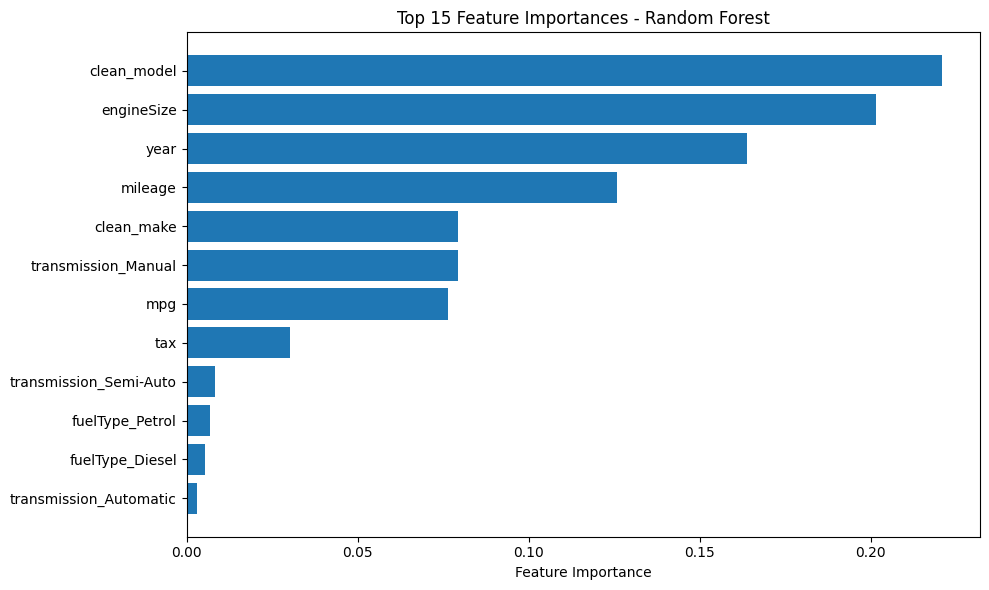

In [28]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances
importances = rf_tuned.feature_importances_
feature_names = choosen_features.columns if hasattr(choosen_features, 'columns') else [f'Feature_{i}' for i in range(choosen_features.shape[1])]

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [29]:
print("\n" + "="*60)
print("MAKING FINAL PREDICTIONS")
print("="*60)

# Make predictions on test set
test_predictions = rf_tuned.predict(choosen_features_test_data)

print(f"✓ Made predictions for {len(test_predictions)} test samples")
print(f"\nPrediction statistics:")
print(f"  Mean: {test_predictions.mean():.2f}")
print(f"  Std:  {test_predictions.std():.2f}")
print(f"  Min:  {test_predictions.min():.2f}")
print(f"  Max:  {test_predictions.max():.2f}")


MAKING FINAL PREDICTIONS
✓ Made predictions for 32567 test samples

Prediction statistics:
  Mean: 16876.79
  Std:  8970.31
  Min:  1853.61
  Max:  88359.53


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [30]:
print("\n" + "="*60)
print("COMPARISON WITH SVM")
print("="*60)

print(f"\nRANDOM FOREST (Tuned):")
print(f"  R²: {r2_tuned:.4f}")
print(f"  RMSE: {rmse_tuned:.2f}")
print(f"  Std Dev Ratio: {y_pred_tuned.std() / y_val.std():.4f}")

print(f"\nSVM (From your previous results):")
print(f"  R²: 0.4876")
print(f"  RMSE: 7003.88")
print(f"  Std Dev Ratio: 0.6147")

improvement = r2_tuned - 0.4876
print(f"\n📈 Improvement with Random Forest: {improvement:.4f} in R²")


COMPARISON WITH SVM

RANDOM FOREST (Tuned):
  R²: 0.9085
  RMSE: 2959.21
  Std Dev Ratio: 0.9114

SVM (From your previous results):
  R²: 0.4876
  RMSE: 7003.88
  Std Dev Ratio: 0.6147

📈 Improvement with Random Forest: 0.4209 in R²
